In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

In [13]:
%matplotlib inline

In [17]:
# STEP 1️⃣ – UPLOAD DATA
print("📂 Please upload your student_feedback.csv file")

# Opens a file picker in Colab for you to upload your CSV file
uploaded = files.upload()

# Extracts the filename of the uploaded file
filename = list(uploaded.keys())[0]


📂 Please upload your student_feedback.csv file


Saving student_feedback.csv to student_feedback (2).csv


In [18]:
# STEP 2️⃣ – CLEAN DATA
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = df.columns.str.strip()
df = df.dropna(how='all')
print("\n📊 Dataset shape:", df.shape)



📊 Dataset shape: (1001, 10)


In [19]:
# STEP 3️⃣ – IDENTIFY RATING COLUMNS
rating_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if not rating_cols:
    print("\n⚠️ No numeric columns detected — trying to convert possible rating text to numbers...")
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')
    rating_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nDetected rating columns:")
print(rating_cols)



Detected rating columns:
['Student ID', 'Well versed with the subject', 'Explains concepts in an understandable way', 'Use of presentations', 'Degree of difficulty of assignments', 'Solves doubts willingly', 'Structuring of the course', 'Provides support for students going above and beyond', 'Course recommendation based on relevance', 'Overall_Average']



📈 Average rating per question:
 Student ID                                              500.000000
Overall_Average                                          60.813742
Well versed with the subject                              7.497502
Explains concepts in an understandable way                6.081918
Use of presentations                                      5.942058
Provides support for students going above and beyond      5.662338
Structuring of the course                                 5.636364
Course recommendation based on relevance                  5.598402
Solves doubts willingly                                   5.474525
Degree of difficulty of assignments                       5.430569
dtype: float64


/tmp/ipython-input-503593922.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette="coolwarm")


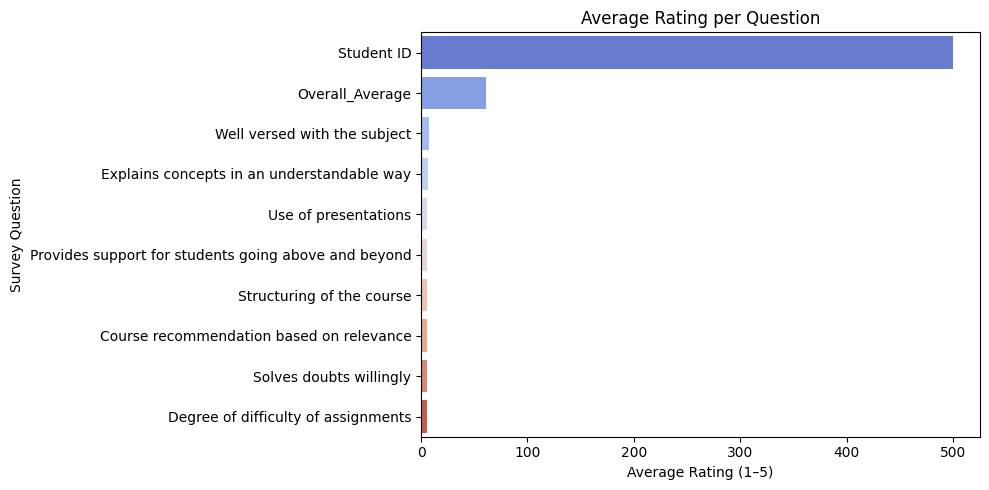

In [20]:
# STEP 4️⃣ – AVERAGE RATING PER QUESTION
avg_ratings = df[rating_cols].mean().sort_values(ascending=False)
print("\n📈 Average rating per question:\n", avg_ratings)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette="coolwarm")
plt.title("Average Rating per Question")
plt.xlabel("Average Rating (1–5)")
plt.ylabel("Survey Question")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


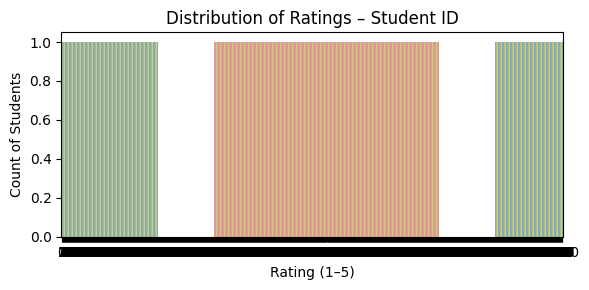

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


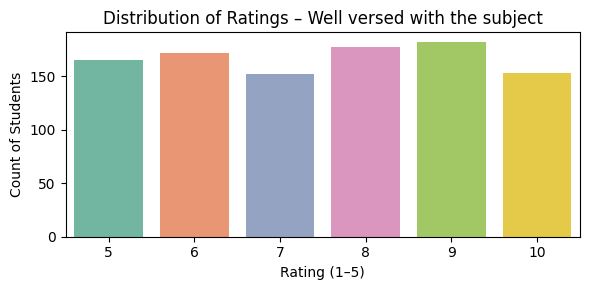

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


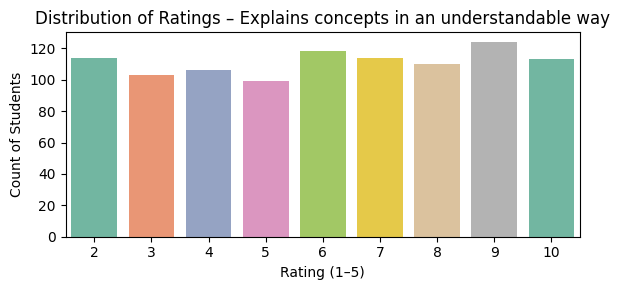

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


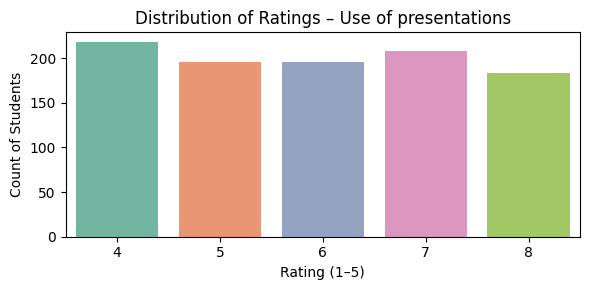

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


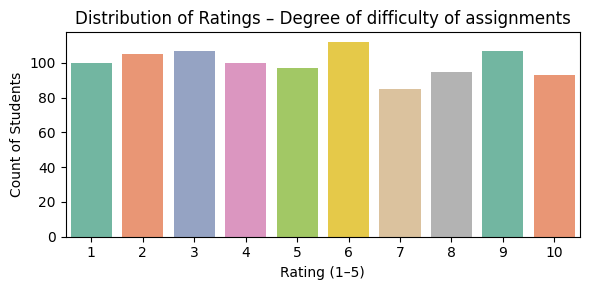

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


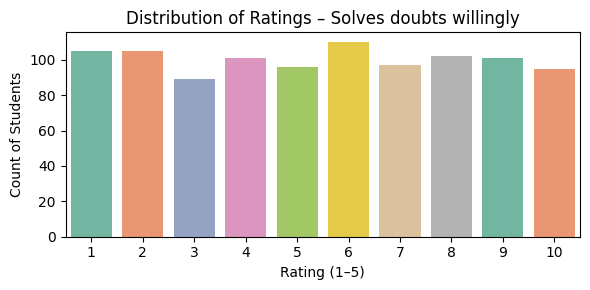

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


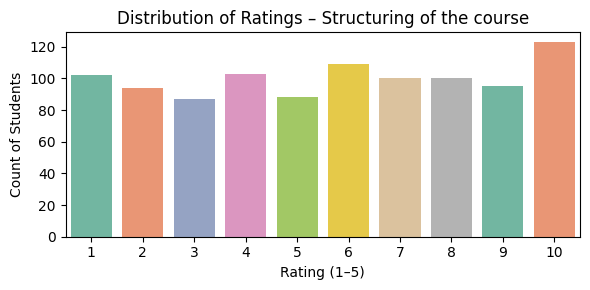

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


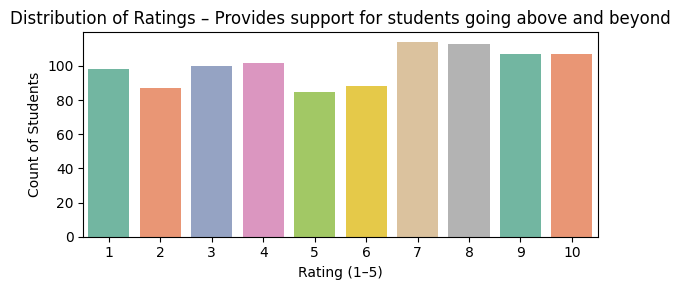

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


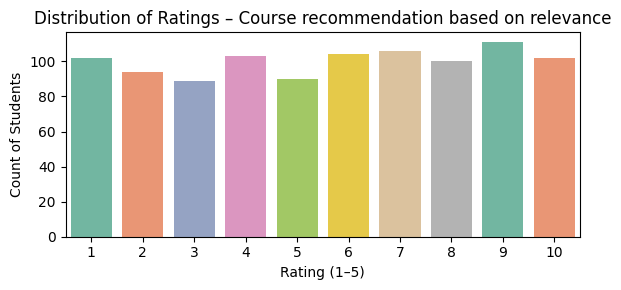

/tmp/ipython-input-3823264515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")


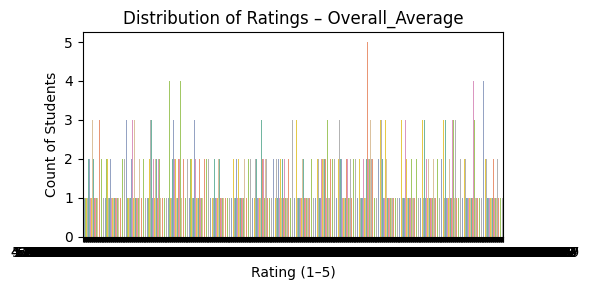

In [21]:
# STEP 5️⃣ – RATING DISTRIBUTIONS
for col in rating_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df, palette="Set2")
    plt.title(f"Distribution of Ratings – {col}")
    plt.xlabel("Rating (1–5)")
    plt.ylabel("Count of Students")
    plt.tight_layout()
    plt.show()


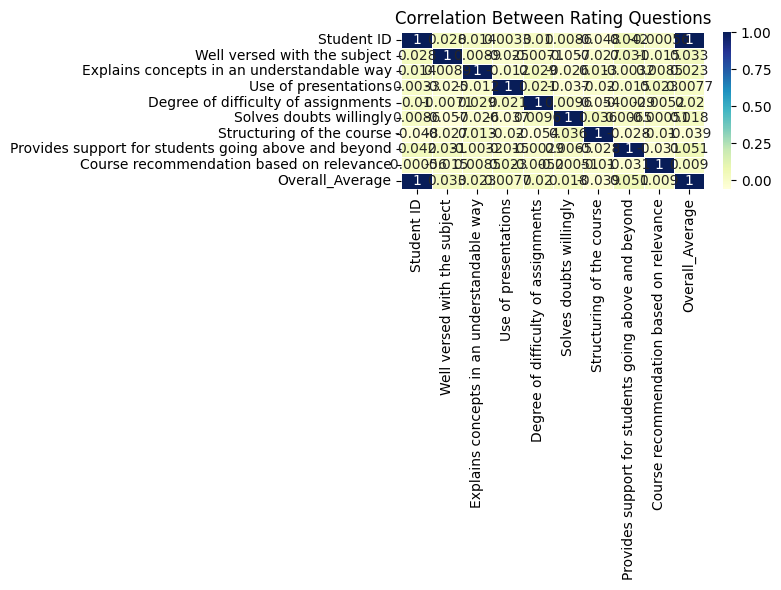

In [22]:
# STEP 6️⃣ – CORRELATION HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(df[rating_cols].corr(), annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title("Correlation Between Rating Questions")
plt.tight_layout()
plt.show()


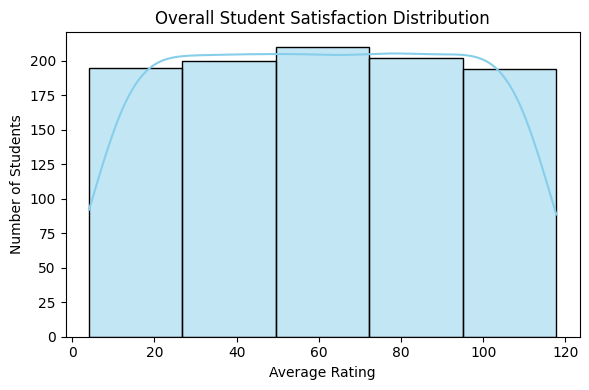


📊 Average Overall Satisfaction: 60.81


In [23]:
# STEP 7️⃣ – OVERALL SATISFACTION SCORE
df["Overall_Average"] = df[rating_cols].mean(axis=1)

plt.figure(figsize=(6,4))
sns.histplot(df["Overall_Average"], bins=5, kde=True, color='skyblue')
plt.title("Overall Student Satisfaction Distribution")
plt.xlabel("Average Rating")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

print("\n📊 Average Overall Satisfaction:", round(df["Overall_Average"].mean(), 2))


In [24]:
# STEP 8️⃣ – EXPORT CLEANED FILE
df.to_csv("Cleaned_Student_Feedback.csv", index=False)
files.download("Cleaned_Student_Feedback.csv")
print("\n✅ Analysis complete! All visuals generated successfully.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Analysis complete! All visuals generated successfully.
